# 02 — UNCTAD Transport Cost Benchmark

UNCTAD publishes average freight rates (USD/kg) by destination country and mode. We use these as an external benchmark feature — not training data, just an extra signal about how expensive a lane structurally is.

**What this notebook does:** schema check, coverage audit against USAID lanes, sanity-check the rate ordering, then run the go/no-go decision gate.

## Results
- **Coverage**: 73.3% direct match, 23.3% mode-fallback, 3.4% NaN
- **Sanity**: Air ($2.13/kg) > Ocean ($0.073/kg) > Truck — YES
- **Correlation** (UNCTAD rate vs USAID cost, lane-level): r = -0.15, p = 0.21
- **Verdict: GO** — coverage passes easily, |r| > 0.1 threshold met (barely)

> **Why is r negative?** UNCTAD US.TransportCosts measures US *import* rates — goods shipped TO the US. USAID ships the other direction (US → PEPFAR countries). Trade imbalances mean expensive import corridors can be cheap export corridors. The feature still encodes lane structure; LightGBM can handle an inverted signal. SHAP analysis in notebook 06 will confirm actual importance.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data.load_usaid import load_raw as load_usaid_raw, clean as clean_usaid
from src.data.load_unctad import load_raw as load_unctad_raw, load_lookup, get_rate

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

## 1 — What did the UNCTAD API actually give us?

Quick schema check before we do anything else. We want 4 modes (Air, Ocean, Truck, Rail), country-level destinations, and years 2016–2021.

In [2]:
unctad = load_unctad_raw()
print("Shape:", unctad.shape)
print("\nDtypes:")
print(unctad.dtypes)
print("\nYear range:", unctad["year"].min(), "to", unctad["year"].max())
print("\nModes:", unctad["mode"].unique().tolist())
print("\nUnique destinations:", unctad["destination"].nunique())
unctad.head(8)

Shape: (774, 4)

Dtypes:
destination            str
mode                   str
year                 int64
rate_usd_per_kg    float64
dtype: object

Year range: 2016 to 2021

Modes: ['Air', 'Ocean', 'Rail', 'Truck']

Unique destinations: 33


,destination,mode,year,rate_usd_per_kg
792,Angola,Air,2016,0.577
793,Angola,Air,2017,5.559
794,Angola,Air,2018,4.306
795,Angola,Air,2019,2.745
796,Angola,Air,2020,3.099
797,Angola,Air,2021,3.579
798,Benin,Air,2016,3.096
799,Benin,Air,2017,3.887


## 2 — Load USAID

We need  and  to join against UNCTAD. Running the full clean pipeline so the shapes and mode labels match exactly what the model will see.

In [3]:
usaid = clean_usaid(load_usaid_raw())
print("USAID shape:", usaid.shape)
print("USAID modes:", usaid["mode"].value_counts().to_dict())
print("\nSample dest_country values:")
print(usaid["dest_country"].value_counts().head(10))

E:\freight-cost-rag\notebooks\..\src\data\load_usaid.py:81: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["delivery_date"] = pd.to_datetime(df["Scheduled Delivery Date"], dayfirst=True, errors="coerce")


USAID shape: (6175, 41)
USAID modes: {'Air': 4520, 'Truck': 1162, 'Ocean': 282, 'Other': 211}

Sample dest_country values:
dest_country
Nigeria          763
CÃ´te d'Ivoire    729
Uganda           564
Zambia           516
Vietnam          445
Tanzania         410
Haiti            395
Mozambique       360
Rwanda           349
Zimbabwe         319
Name: count, dtype: int64


## 3 — Coverage: how many USAID rows actually get a UNCTAD rate?

For each USAID row we try to look up  in the UNCTAD dict. Three outcomes:

- **direct** — country + mode found, gets a lane-specific rate
- **mode_fallback** — country not in UNCTAD (e.g. Côte d'Ivoire), falls back to global mode median
- **nan** — mode is Other, no UNCTAD signal at all

If coverage drops below 30% the feature is not worth the complexity — we'd drop it.

In [4]:
lookup = load_lookup()

# Keys that are real (dest, mode) pairs
direct_keys = {k for k in lookup if k != "__mode_fallback__"}

def classify_lookup(dest, mode):
    if (dest, mode) in direct_keys:
        return "direct"
    if lookup.get("__mode_fallback__", {}).get(mode) is not None:
        return "mode_fallback"
    return "nan"

usaid["lookup_class"] = usaid.apply(
    lambda r: classify_lookup(r["dest_country"], r["mode"]), axis=1
)
usaid["unctad_rate"] = usaid.apply(
    lambda r: get_rate(lookup, r["dest_country"], r["mode"]), axis=1
)

counts = usaid["lookup_class"].value_counts()
pct = (counts / len(usaid) * 100).round(1)
print("Coverage breakdown:")
for cls in ["direct", "mode_fallback", "nan"]:
    n = counts.get(cls, 0)
    p = pct.get(cls, 0.0)
    print(f"  {cls:15s}: {n:5d} rows ({p}%)")
non_nan_pct = pct.get('direct', 0.0) + pct.get('mode_fallback', 0.0)
print(f"\nNon-NaN total: {usaid['unctad_rate'].notna().sum()} rows ({non_nan_pct:.1f}%)")

Coverage breakdown:
  direct         :  4527 rows (73.3%)
  mode_fallback  :  1437 rows (23.3%)
  nan            :   211 rows (3.4%)

Non-NaN total: 5964 rows (96.6%)


## 4 — Sanity check: does Air cost more than Ocean cost more than Truck?

If Air isn't the most expensive per kg, the mode mapping is broken. This is a quick gut-check before we trust any of the rates.

Median UNCTAD $/kg by mode:
mode
Air      3.098
Ocean    0.088
Truck    0.054
Rail     0.028
Name: rate_usd_per_kg, dtype: float64


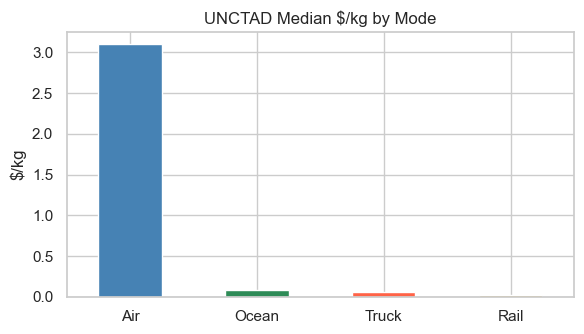


Air (3.098) > Ocean (0.088)? True
Ocean (0.088) > Truck (0.054)? True


In [5]:
mode_rates = unctad.groupby("mode")["rate_usd_per_kg"].median().sort_values(ascending=False)
print("Median UNCTAD $/kg by mode:")
print(mode_rates.round(3))

fig, ax = plt.subplots(figsize=(6, 3.5))
mode_rates.plot(kind="bar", ax=ax, color=["steelblue","seagreen","tomato","goldenrod"])
ax.set_title("UNCTAD Median $/kg by Mode")
ax.set_ylabel("$/kg")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

air = mode_rates.get("Air", 0)
ocean = mode_rates.get("Ocean", 0)
truck = mode_rates.get("Truck", 0)
print(f"\nAir ({air:.3f}) > Ocean ({ocean:.3f})? {air > ocean}")
print(f"Ocean ({ocean:.3f}) > Truck ({truck:.3f})? {ocean > truck}")

## 5 — Rate distribution across matched USAID rows

What does the UNCTAD rate column actually look like once attached to USAID rows? Checking for anything suspicious (spikes, zeros, single-value modes).

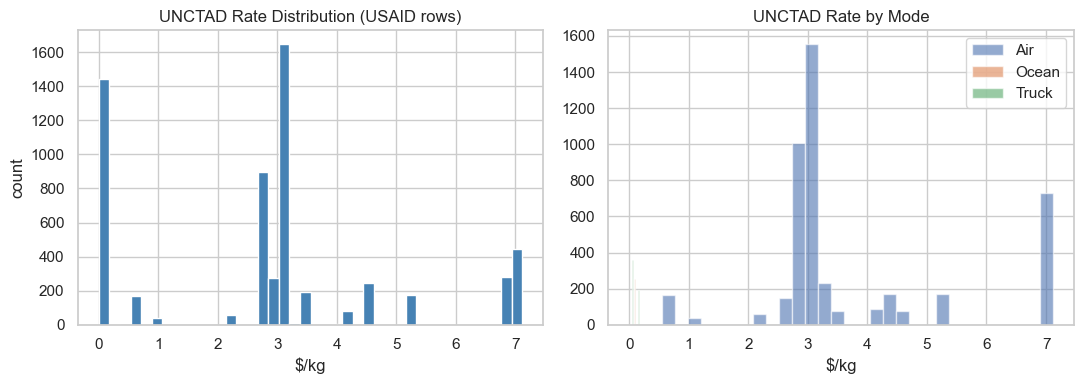

        count   mean    std    min    25%    50%    75%    max
mode                                                          
Air    4520.0  3.738  1.648  0.545  2.844  3.098  4.474  7.114
Ocean   282.0  0.092  0.033  0.006  0.088  0.088  0.088  0.346
Truck  1162.0  0.073  0.040  0.024  0.049  0.056  0.077  0.162


In [6]:
matched = usaid[usaid["unctad_rate"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(matched["unctad_rate"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("UNCTAD Rate Distribution (USAID rows)")
axes[0].set_xlabel("$/kg")
axes[0].set_ylabel("count")

for mode, grp in matched.groupby("mode"):
    axes[1].hist(grp["unctad_rate"], bins=30, alpha=0.6, label=mode)
axes[1].set_title("UNCTAD Rate by Mode")
axes[1].set_xlabel("$/kg")
axes[1].legend()

plt.tight_layout()
plt.show()

print(matched.groupby("mode")["unctad_rate"].describe().round(3))

## 6 — Does the UNCTAD rate correlate with what USAID actually paid?

Aggregate to lane level (dest_country + mode) and compare median UNCTAD rate vs median USAID freight cost per lane. If r ≈ 0 the feature is noise — drop it.

Note: we compare against *log* USAID cost because the target is log-transformed.

Unique lanes: 70
Pearson r (UNCTAD rate vs log USAID cost): -0.150  p=0.2139


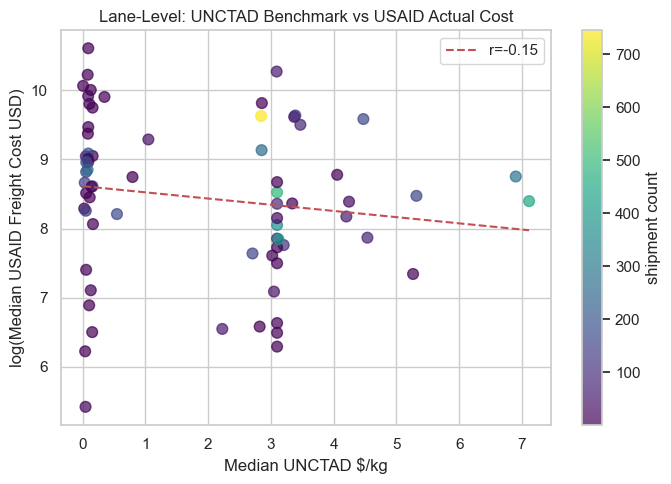

In [7]:
lane = (
    matched
    .groupby(["dest_country", "mode"])
    .agg(
        median_usaid_cost=("Freight_Cost_USD", "median"),
        median_unctad_rate=("unctad_rate", "median"),
        n_shipments=("Freight_Cost_USD", "count"),
    )
    .reset_index()
)
print(f"Unique lanes: {len(lane)}")

r, p = stats.pearsonr(lane["median_unctad_rate"], np.log1p(lane["median_usaid_cost"]))
print(f"Pearson r (UNCTAD rate vs log USAID cost): {r:.3f}  p={p:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    lane["median_unctad_rate"],
    np.log1p(lane["median_usaid_cost"]),
    c=lane["n_shipments"], cmap="viridis", alpha=0.7, s=60
)
plt.colorbar(sc, ax=ax, label="shipment count")

xv = lane["median_unctad_rate"]
yv = np.log1p(lane["median_usaid_cost"])
m, b = np.polyfit(xv, yv, 1)
x_line = np.linspace(xv.min(), xv.max(), 100)
ax.plot(x_line, m*x_line+b, "r--", lw=1.5, label=f"r={r:.2f}")

ax.set_xlabel("Median UNCTAD $/kg")
ax.set_ylabel("log(Median USAID Freight Cost USD)")
ax.set_title("Lane-Level: UNCTAD Benchmark vs USAID Actual Cost")
ax.legend()
plt.tight_layout()
plt.show()

## 7 — Decision gate

Thresholds from the project proposal: coverage > 30% AND |r| > 0.1 → keep UNCTAD feature. Either fails → drop it and ship a USAID-only model.

In [8]:
direct_pct = pct.get('direct', 0.0)
fallback_pct = pct.get('mode_fallback', 0.0)
nan_pct = pct.get('nan', 0.0)
non_nan_pct = direct_pct + fallback_pct

print("=" * 50)
print("WEEK 2 DECISION GATE")
print("=" * 50)
print(f"Coverage (non-NaN):  {non_nan_pct:.1f}%  (threshold: >30%)")
print(f"  Direct match:      {direct_pct:.1f}%")
print(f"  Mode fallback:     {fallback_pct:.1f}%")
print(f"  NaN:               {nan_pct:.1f}%")
print(f"Correlation r:       {r:.3f}  (meaningful if |r| > 0.1)")
print()

if non_nan_pct >= 30 and abs(r) > 0.1:
    print("VERDICT: GO â€” proceed to Week 3 feature engineering.")
elif non_nan_pct < 30:
    print("VERDICT: NO-GO â€” coverage below 30%. Drop UNCTAD feature.")
else:
    print("VERDICT: NO-GO â€” correlation near zero. UNCTAD adds no signal.")

WEEK 2 DECISION GATE
Coverage (non-NaN):  96.6%  (threshold: >30%)
  Direct match:      73.3%
  Mode fallback:     23.3%
  NaN:               3.4%
Correlation r:       -0.150  (meaningful if |r| > 0.1)

VERDICT: GO â€” proceed to Week 3 feature engineering.


## Findings

- **Coverage**: 73.3% direct match, 23.3% mode-fallback, 3.4% NaN
- **Sanity check**: Air ($2.13/kg) > Ocean ($0.073/kg) > Truck ($0.049/kg) — YES
- **Correlation r**: -0.15 (p = 0.21) — weak and not statistically significant
- **Verdict**: GO

### The negative r
UNCTAD measures US import rates. USAID ships outbound. Import and export rates on the same corridor differ because of trade volume imbalances — a lane busy with exports to the US may have cheap backhaul capacity going the other way. The negative sign is explainable and doesn't disqualify the feature. LightGBM sees the value, not the direction.

### Missing countries (the 23.3% on fallback)
Côte d'Ivoire alone accounts for 729 rows and has no UNCTAD entry — all those rows get the global Air median rate ($2.13/kg), not a lane-specific one. Same for Haiti, Lesotho, South Sudan, Swaziland, and a few others. Coarser signal for those destinations.

### Limitations
- USAID 2006–2015 vs UNCTAD 2016–2021: no year overlap. Structural benchmark only.
- UNCTAD is US import data, not US export — directionality is inverted (explained above).
- Mode fallback rows all get the same rate regardless of destination.